In [ ]:
# some useful libraries for this notebook
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# API key is required; you can get one for free by signing up
API_KEY = "your_key_here"  # Replace with your actual OpenAlex API key

### 1) Retrieve a single work by identifier

This code snippet demonstrates how to look up a work by its DOI using the OpenAlex API, extract key metadata fields, and print them in a readable format. 

You can modify the `IDENTIFIER` variable to look up different works or use other identifiers like: DOI, PMID, PMCID, MAG ID, OpenAlex ID.

API docs: https://help.openalex.org/api/filtering/


In [ ]:
### Settings
# Replace with the identifier you want to look up
IDENTIFIER = "https://doi.org/10.1038/s41467-025-56573-8"

In [27]:
### Fetch
# We are going to use the "works" endpoint to look up a work by its DOI
url = f"https://api.openalex.org/works/doi:{IDENTIFIER}"
params = {"api_key": API_KEY}

# Make the API request
response = requests.get(url, params=params)
response.raise_for_status() # raises an error for 4xx/5xx responses

# The response is a JSON object; we convert it to a Python dictionary
work = response.json()

In [28]:
### Display key metadata
# Tip: to check available fields, you can print `work.keys()` or refer to the API documentation
print("Title      :", work.get("title"))
print("DOI        :", work.get("doi"))
print("Year       :", work.get("publication_year"))
print("Type       :", work.get("type"))
print("Citations  :", work.get("cited_by_count"))

# Some fields contain nested data; for example, `authorships` is a list of authorship objects, each containing an `author` object
authors = [a["author"]["display_name"] for a in work.get("authorships", [])]
print("Authors    :", ", ".join(authors))

# Open-access status is nested under `open_access`
print("OA status  :", work.get("open_access", {}).get("oa_status"))


Title      : Artificial intelligence for modeling and understanding extreme weather and climate events
DOI        : https://doi.org/10.1038/s41467-025-56573-8
Year       : 2025
Type       : article
Citations  : 242
Authors    : Gustau Camps‐Valls, Miguel‐Ángel Fernández‐Torres, Kai-Hendrik Cohrs, Aaron Hohl, Andrea Castelletti, Aytaç Paçal, Claire Nicolle Robin, Francesco Martinuzzi, Ioannis Papoutsis, Ioannis Prapas, Jorge Pérez‐Aracil, Katja Weigel, Maria Gonzalez-Calabuig, Markus Reichstein, Martin Rabel, Matteo Giuliani, Miguel D. Mahecha, Oana-Iuliana Popescu, Óscar J. Pellicer-Valero, Said Ouala, Sancho Salcedo‐Sanz, Sebastian Sippel, Spyros Kondylatos, Tamara Happé, Tristan Williams
OA status  : gold


### 2) Retrieve multiple works from a list of DOIs

This section demonstrates how to query multiple DOIs and build a dataset with the fetched metadata; we will build tables for publications, authors, and topics.

API docs: https://help.openalex.org/api/filtering/


In [29]:
### Settings
# Option A: hardcoded list of DOIs
DOIS = [
    "10.1016/s1474-4422(25)00270-4",
    "10.1038/s41467-025-56573-8",
    "10.17185/duepublico/83794",
    "10.1186/s13195-024-01666-7",
    "10.1186/s13045-024-01634-6",
    "10.1038/s41591-025-03622-w",
    "10.1038/s41591-024-03485-7",
    "10.1111/joor.13985",
    "10.1063/5.0258496",
    "10.1038/s41571-025-01041-x",
    "10.2196/60432",
    "10.1038/s41591-025-03902-5"
]
 
# Option B: load from a file (comment out Option A and uncomment one of these)
# FILE = "dois.csv"    # must have a column named "doi"
# FILE = "dois.xlsx"
# DOIS = pd.read_csv(FILE)["doi"].dropna().unique().tolist()
# DOIS = pd.read_excel(FILE)["doi"].dropna().unique().tolist()


# Remove duplicates
dois = list(set(DOIS))
print(f"{len(dois)} unique DOIs to look up.")
 

12 unique DOIs to look up.


In [30]:
### Fetch
# Initialize lists to store results
works, not_found = [], []

# Loop over DOIs and fetch work metadata; use tqdm to show progress
for doi in tqdm(DOIS, desc="Fetching works"):
    # For each DOI, we make a request to the "works" endpoint with the DOI as an identifier
    response = requests.get(
        f"https://api.openalex.org/works/doi:{doi}",
        params={"api_key": API_KEY},
    )
    # If the DOI is not found, the API returns a 404 status code and we add it to the not_found list
    if response.status_code == 404:
        not_found.append(doi)
        continue

    # For other status codes, we raise an error if it's not a successful response
    response.raise_for_status()
    # If the request is successful, we add the work metadata to the works list
    works.append(response.json())

# After the loop, we can check how many works were found and how many DOIs were not found 
if not_found:
    print(f"{len(not_found)} DOIs not found: {not_found}")

Fetching works: 100%|██████████| 12/12 [00:04<00:00,  2.44it/s]


In [31]:
### Build and save tables 
# Initialize empty lists to store rows for each table
publications, authors, topics = [], [], []
 
# For each work, we extract relevant metadata and append it to the publications list; we also extract authorship and topic information to build the authors and topics tables
for work in works:
    wid = work["id"]
 
    publications.append({
        "id":             wid,
        "title":          work.get("title"),
        "doi":            work.get("doi"),
        "year":           work.get("publication_year"),
        "type":           work.get("type"),
        "cited_by_count": work.get("cited_by_count"),
        "oa_status":      work.get("open_access", {}).get("oa_status"),
    })
 
    for auth in work.get("authorships", []):
        authors.append({
            "work_id":          wid,
            "author_id":        auth["author"]["id"],
            "author_name":      auth["author"]["display_name"],
            "position":         auth.get("author_position"),
            "is_corresponding": auth.get("is_corresponding"),
        })
 
    for topic in work.get("topics", []):
        topics.append({
            "work_id":    wid,
            "topic_id":   topic["id"],
            "topic_name": topic["display_name"],
            "score":      topic.get("score"),
            "field":      topic.get("field", {}).get("display_name"),
            "domain":     topic.get("domain", {}).get("display_name"),
        })

# Convert lists of dictionaries to DataFrames
df_pub    = pd.DataFrame(publications)
df_auth   = pd.DataFrame(authors)
df_topics = pd.DataFrame(topics)
 
# Save to CSV files
df_pub.to_csv("publications.csv", index=False)
df_auth.to_csv("authors.csv", index=False)
df_topics.to_csv("topics.csv", index=False)

# Print summary of results 
print(f"Saved {len(df_pub)} publications, {len(df_auth)} authorships, {len(df_topics)} topics.")

Saved 12 publications, 289 authorships, 36 topics.


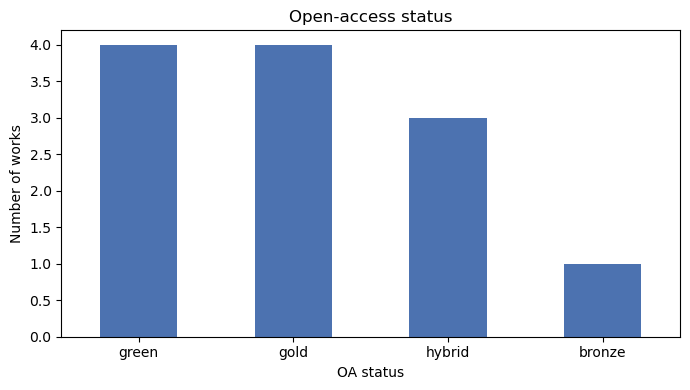

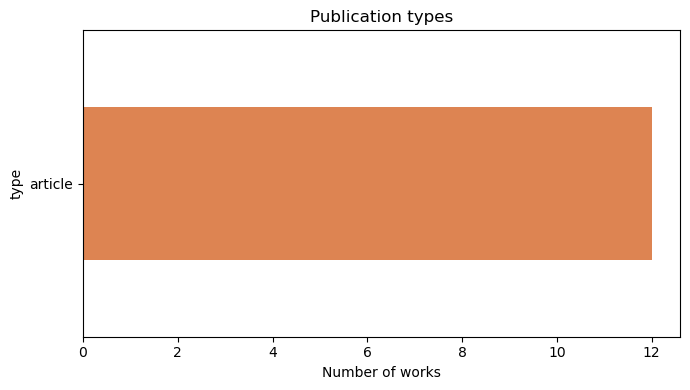

In [32]:
### Charts
# We can create simple charts to visualize the distribution of open-access status and publication types in our dataset using matplotlib 

# 1. Open-access status distribution
oa_counts = df_pub["oa_status"].value_counts()
 
fig, ax = plt.subplots(figsize=(7, 4))
oa_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Open-access status")
ax.set_xlabel("OA status")
ax.set_ylabel("Number of works")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("chart_oa_status.png", dpi=150)
plt.show()
 
# 2. Publication type distribution
type_counts = df_pub["type"].value_counts()
 
fig, ax = plt.subplots(figsize=(7, 4))
type_counts.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Publication types")
ax.set_xlabel("Number of works")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_work_types.png", dpi=150)
plt.show()

### 3) All works from an institution for a given year

This section demonstrates how to query works by an institution in a specific year, and then build tables of publications, authors, and topics. We will use pagination to retrieve all results if there are more than 200 (the default page size).

API docs: https://help.openalex.org/api/paging/

In [33]:
### Settings
# Choose the institution
ROR_ID = "https://ror.org/008xxew50"
# Choose the year
YEAR = 2025
# Tune the number of results per page (max 200)
PER_PAGE = 200

In [34]:
### Fetch
# Build the filter string to query works authored by the specified institution in the specified year
filter_str = f"authorships.institutions.ror:{ROR_ID},publication_year:{YEAR}"

# Initialize an empty list to store all works and a cursor for pagination
all_works = []
cursor = "*"

# We will loop until there are no more pages of results; in each iteration, we make a request to the "works" endpoint with the filter and cursor parameters, and we append the results
while cursor:
    params = {
        "filter": filter_str,
        "per-page": PER_PAGE,
        "cursor": cursor,
        "api_key": API_KEY 
    }

    response = requests.get("https://api.openalex.org/works", params=params)
    response.raise_for_status()
    data = response.json()

    all_works.extend(data.get("results", []))
    cursor = data.get("meta", {}).get("next_cursor")

    total = data["meta"]["count"]
    print(f"Fetched {len(all_works)} / {total} works …")

Fetched 200 / 7858 works …
Fetched 400 / 7858 works …
Fetched 600 / 7858 works …
...

In [35]:
### Build and save tables
# Initialize empty lists to store rows for each table
publications, authors, topics = [], [], []

# For each work, we extract relevant metadata and append it to the publications list; we also extract authorship and topic information to build the authors and topics tables
for work in all_works:
    wid = work["id"]

    publications.append({
        "id":             wid,
        "title":          work.get("title", ""),
        "doi":            work.get("doi", ""),
        "year":           work.get("publication_year", ""),
        "type":           work.get("type", ""),
        "cited_by_count": work.get("cited_by_count", 0),
        "oa_status":      work.get("open_access", {}).get("oa_status", ""),
    })

    for auth in work.get("authorships", []):
        authors.append({
            "work_id":          wid,
            "author_id":        auth["author"]["id"],
            "author_name":      auth["author"]["display_name"],
            "position":         auth.get("author_position", ""),
            "is_corresponding": auth.get("is_corresponding", False),
        })

    for topic in work.get("topics", []):
        topics.append({
            "work_id":    wid,
            "topic_id":   topic["id"],
            "topic_name": topic["display_name"],
            "score":      topic.get("score", ""),
            "field":      topic.get("field", {}).get("display_name", ""),
            "domain":     topic.get("domain", {}).get("display_name", ""),
        })
        
# Convert lists of dictionaries to DataFrames
df_pub    = pd.DataFrame(publications)
df_auth   = pd.DataFrame(authors)
df_topics = pd.DataFrame(topics)
 
# Save to CSV files
df_pub.to_csv("publications.csv", index=False)
df_auth.to_csv("authors.csv", index=False)
df_topics.to_csv("topics.csv", index=False)

# Print summary of results 
print(f"Saved {len(df_pub)} publications, {len(df_auth)} authorships, {len(df_topics)} topics.")

Saved 7858 publications, 76539 authorships, 20587 topics.


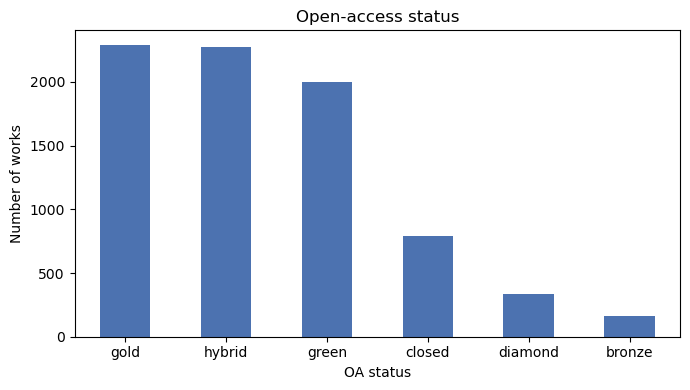

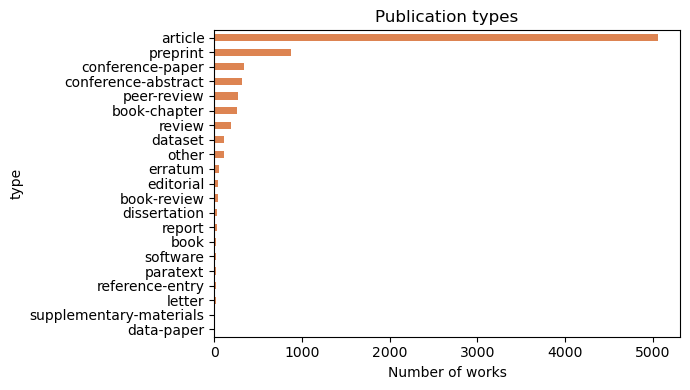

In [36]:
### Charts
# We can create simple charts to visualize the distribution of open-access status and publication types in our dataset using matplotlib 

# 1. Open-access status distribution
oa_counts = df_pub["oa_status"].value_counts()
 
fig, ax = plt.subplots(figsize=(7, 4))
oa_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Open-access status")
ax.set_xlabel("OA status")
ax.set_ylabel("Number of works")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("chart_oa_status.png", dpi=150)
plt.show()
 
# 2. Publication type distribution
type_counts = df_pub["type"].value_counts()
 
fig, ax = plt.subplots(figsize=(7, 4))
type_counts.plot(kind="barh", ax=ax, color="#DD8452")
ax.set_title("Publication types")
ax.set_xlabel("Number of works")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart_work_types.png", dpi=150)
plt.show()

### 4) Data quality checks

Before analyzing a dataset from OpenAlex, you may want to check a few things, for example:

- **Retracted works** - papers that have been officially withdrawn, but are still indexed in OpenAlex.
- **Paratext** - front covers, tables of contents, corrections, editorials. These can inflate output counts if you're not expecting them.
- **Missing abstracts** - many publishers don't allow OpenAlex to share the abstract text, even though the work itself is indexed. If your analysis relies on abstracts (e.g. text mining), you need to know how much of your data is affected.

This section reuses the `all_works` list fetched in section 3 (all works from an institution in a given year) and produces a plain-language summary. If you haven't run section 3 yet, run it first.


In [37]:
### Check data quality flags
# We go through every work in all_works (from section 3) and count how many
# fall into each quality-flag category. Nothing here is deleted -- we're just counting.

total_works = len(all_works)

retracted_count = 0
paratext_count = 0
missing_abstract_count = 0

for work in all_works:

    # 1) Is this work marked as retracted?
    # .get("is_retracted", False) means: look up "is_retracted"; if it's not there, assume False.
    if work.get("is_retracted", False):
        retracted_count = retracted_count + 1

    # 2) Is this "paratext"?
    # (front covers, tables of contents, corrections, etc. -- OpenAlex marks these with type == "paratext")
    if work.get("type") == "paratext":
        paratext_count = paratext_count + 1

    # 3) Does this work have an abstract available?
    # OpenAlex stores abstracts in a field called abstract_inverted_index.
    # If that field is empty (None), it means no abstract text is available for this work.
    if work.get("abstract_inverted_index") is None:
        missing_abstract_count = missing_abstract_count + 1

### Report -- printed in plain language, no jargon
print(f"Total works checked: {total_works}")
print()
print(f"Retracted works       : {retracted_count}  ({retracted_count/total_works:.1%} of the dataset)")
print(f"Paratext (not articles): {paratext_count}  ({paratext_count/total_works:.1%} of the dataset)")
print(f"Missing abstracts      : {missing_abstract_count}  ({missing_abstract_count/total_works:.1%} of the dataset)")


Total works checked: 7858

Retracted works       : 1  (0.0% of the dataset)
Paratext (not articles): 18  (0.2% of the dataset)
Missing abstracts      : 1249  (15.9% of the dataset)


In [38]:
### Optional: build a "clean" version of the dataset
# This keeps only works that are NOT retracted and NOT paratext.

clean_works = []

for work in all_works:
    is_retracted = work.get("is_retracted", False)
    is_paratext = work.get("type") == "paratext"

    if not is_retracted and not is_paratext:
        clean_works.append(work)

print(f"Kept {len(clean_works)} out of {len(all_works)} works after removing retracted works and paratext.")


Kept 7839 out of 7858 works after removing retracted works and paratext.


### 5) Using the OpenAlex Query Language (OQL)

OQL is a newer query interface that sits alongside the classic `filter=` URL syntax used above. It reads like a sentence (`works where year is (2020)`), supports richer boolean nesting than the classic URL can express, and every query has an equivalent JSON form (OQO) for building queries programmatically.


API docs: https://help.openalex.org/api/oql/


In [39]:
### Learn OQL from a filter you already know
# Any classic /works?filter=... response carries meta.x_query.oql, the OQL equivalent of that same request.
# Here we reuse the institution+year filter from section 3 above and read back its OQL form.

response = requests.get(
    "https://api.openalex.org/works",
    params={"filter": filter_str, "per_page": 1, "api_key": API_KEY},
)
response.raise_for_status()
x_query = response.json()["meta"]["x_query"]

print("OQL  :", x_query["oql"])


OQL  : works where ROR ID is (https://ror.org/008xxew50) and year is (2025)


In [40]:
### Settings
# Write the same kind of query directly in OQL. This reproduces the section-3 query
# (works from an institution in a given year) but is easy to extend with boolean logic
# that the classic filter syntax cannot express, e.g. nested AND/OR groups.
OQL_QUERY = f'works where institutions.ror is ("{ROR_ID}") and year is ({YEAR})'

### Fetch
response = requests.get(
    "https://api.openalex.org/",
    params={"oql": OQL_QUERY, "per-page": 5, "api_key": API_KEY},
)
response.raise_for_status()
oql_result = response.json()

print("Count:", oql_result["meta"]["count"])


Count: 7858


OQL also lets you fold a `group by` into the query itself, returning aggregated counts directly instead of paging through every result. Handy for quick breakdowns (e.g. publication type or OA status counts) without building a DataFrame first.


In [41]:
### Group counts directly in the query
OQL_GROUPBY_QUERY = f'works where institutions.ror is ("{ROR_ID}") and year is ({YEAR}) group by type'

response = requests.get(
    "https://api.openalex.org/",
    params={"oql": OQL_GROUPBY_QUERY, "api_key": API_KEY},
)
response.raise_for_status()
group_result = response.json()

df_groupby = pd.DataFrame(group_result["group_by"])
df_groupby


,key,key_display_name,count
0,https://openalex.org/types/article,article,5059
1,https://openalex.org/types/preprint,preprint,871
2,https://openalex.org/types/conference-paper,conference-paper,346
3,https://openalex.org/types/conference-abstract,conference-abstract,323
4,https://openalex.org/types/peer-review,peer-review,271
5,https://openalex.org/types/book-chapter,book-chapter,255
6,https://openalex.org/types/review,review,187
7,https://openalex.org/types/dataset,dataset,117
8,https://openalex.org/types/other,other,110
9,https://openalex.org/types/erratum,erratum,52
